In [1]:
%pip install pymysql

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from sqlalchemy import create_engine, inspect
from datetime import datetime, timedelta

def mysql_table_name(engine, logical_name: str) -> str:
    """
    Return the table name as MySQL stored it.
    This avoids case-sensitivity issues.
    """
    key = logical_name.lower()

    for name in inspect(engine).get_table_names():
        if name.lower() == key:
            return name

    return logical_name


# --------------------------------
# MySQL connection configuration
# --------------------------------

DB_HOST = "localhost"
DB_PORT = "3306"
DB_NAME = "noodles_dw"
DB_USER = "root"

# Put the MySQL password you created during installation here
DB_PASSWORD = "Reecedaman210"


# --------------------------------
# Create MySQL connection
# --------------------------------

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    echo=False
)


# --------------------------------
# Test connection
# --------------------------------

with engine.connect() as conn:
    print("✅ Connected to MySQL database:", DB_NAME)

print("📊 This is your Data Warehouse (MySQL)!")

✅ Connected to MySQL database: noodles_dw
📊 This is your Data Warehouse (MySQL)!


In [3]:
create_dim_currency = """
CREATE TABLE IF NOT EXISTS DimCurrency (
    CurrencyKey INT AUTO_INCREMENT PRIMARY KEY,
    Symbol VARCHAR(20) NOT NULL UNIQUE,
    CurrencyName VARCHAR(100),
    BaseCurrency VARCHAR(20),
    Website VARCHAR(255),
    CirculatingSupply DOUBLE,
    MaxSupply VARCHAR(50),
    LoadDate DATETIME DEFAULT CURRENT_TIMESTAMP
);
"""

with engine.begin() as conn:
    conn.exec_driver_sql(create_dim_currency)

print("✅ DimCurrency table created!")

✅ DimCurrency table created!


In [4]:
create_dim_date = """
CREATE TABLE IF NOT EXISTS DimDate (
    DateKey INT PRIMARY KEY,
    FullDate DATE NOT NULL,

    Year INT,
    Quarter INT,
    Month INT,
    MonthName VARCHAR(20),

    Week INT,
    DayOfMonth INT,
    DayOfWeek INT,
    DayName VARCHAR(20),

    IsWeekend TINYINT
);
"""

with engine.begin() as conn:
    conn.exec_driver_sql(create_dim_date)

print("✅ DimDate table created!")

✅ DimDate table created!


In [5]:
create_dim_platform = """
CREATE TABLE IF NOT EXISTS DimPlatform (
    PlatformKey INT AUTO_INCREMENT PRIMARY KEY,
    PlatformName VARCHAR(100) NOT NULL UNIQUE,
    PlatformDescription VARCHAR(255)
);
"""

with engine.begin() as conn:
    conn.exec_driver_sql(create_dim_platform)

print("✅ DimPlatform table created!")

✅ DimPlatform table created!


In [6]:
create_fact_social = """
CREATE TABLE IF NOT EXISTS FactSocialEngagement (
    EngagementKey INT AUTO_INCREMENT PRIMARY KEY,

    CurrencyKey INT NOT NULL,
    DateKey INT NOT NULL,
    PlatformKey INT NOT NULL,

    PostId VARCHAR(255),

    Likes INT DEFAULT 0,
    Retweets INT DEFAULT 0,
    Comments INT DEFAULT 0,
    Impressions INT DEFAULT 0,

    EngagementScore DECIMAL(18,4),
    LoadDate DATETIME DEFAULT CURRENT_TIMESTAMP,

    CONSTRAINT fk_fact_currency
        FOREIGN KEY (CurrencyKey) REFERENCES DimCurrency(CurrencyKey),

    CONSTRAINT fk_fact_date
        FOREIGN KEY (DateKey) REFERENCES DimDate(DateKey),

    CONSTRAINT fk_fact_platform
        FOREIGN KEY (PlatformKey) REFERENCES DimPlatform(PlatformKey)
);
"""

with engine.begin() as conn:
    conn.exec_driver_sql(create_fact_social)

print("✅ FactSocialEngagement table created!")

✅ FactSocialEngagement table created!


In [7]:
import json
import numpy as np
from IPython.display import display
from sqlalchemy.types import VARCHAR, FLOAT

print("📦 STEP 6 — LOAD DIMCURRENCY")
print("=" * 60)

# ------------------------------------------------------------
# 1. Load currency data from JSON
# ------------------------------------------------------------

df_currency = pd.read_json("v2_token.json")

print(f"📦 Raw records loaded: {len(df_currency):,}")
print(f"📋 Available columns: {df_currency.columns.tolist()}")


# ------------------------------------------------------------
# 2. Helper function — safely find a column
# ------------------------------------------------------------

def find_column(df, possible_names, default=None):
    for name in possible_names:
        if name in df.columns:
            return name
    return default


# ------------------------------------------------------------
# 3. Detect the actual columns in the JSON
# ------------------------------------------------------------

symbol_col = find_column(
    df_currency,
    ["symbol", "Symbol"]
)

name_col = find_column(
    df_currency,
    ["currency_desc", "currency_name", "name", "Name", "description"],
    default=symbol_col
)

base_currency_col = find_column(
    df_currency,
    ["base_currency", "baseCurrency", "BaseCurrency"]
)

website_col = find_column(
    df_currency,
    ["website", "Website", "url"]
)

circulating_col = find_column(
    df_currency,
    ["circulating_supply", "circulatingSupply", "CirculatingSupply"]
)

max_supply_col = find_column(
    df_currency,
    ["max_supply", "maxSupply", "MaxSupply"]
)


print("\n🔎 COLUMN MAPPING")
print("-" * 60)
print(f"Symbol              → {symbol_col}")
print(f"Currency Name       → {name_col}")
print(f"Base Currency       → {base_currency_col}")
print(f"Website             → {website_col}")
print(f"Circulating Supply  → {circulating_col}")
print(f"Max Supply          → {max_supply_col}")


# ------------------------------------------------------------
# 4. Create the dimension dataframe
# ------------------------------------------------------------

dim_currency = pd.DataFrame()

dim_currency["Symbol"] = (
    df_currency[symbol_col].astype(str).str.strip()
    if symbol_col
    else ""
)

dim_currency["CurrencyName"] = (
    df_currency[name_col].astype(str).str.strip()
    if name_col
    else dim_currency["Symbol"]
)

dim_currency["BaseCurrency"] = (
    df_currency[base_currency_col]
    if base_currency_col
    else None
)

dim_currency["Website"] = (
    df_currency[website_col]
    if website_col
    else None
)

dim_currency["CirculatingSupply"] = (
    df_currency[circulating_col]
    if circulating_col
    else None
)

dim_currency["MaxSupply"] = (
    df_currency[max_supply_col]
    if max_supply_col
    else None
)


# ------------------------------------------------------------
# 5. Clean text fields
# ------------------------------------------------------------

def to_safe_text(x):
    """
    Convert complex values such as lists/dicts into safe
    strings for MySQL VARCHAR/TEXT columns.
    """
    
    if x is None:
        return None

    if isinstance(x, float) and pd.isna(x):
        return None

    if isinstance(x, (list, tuple, np.ndarray)):
        if len(x) == 0:
            return None
        
        first = x[0]
        
        if isinstance(first, (str, int, float)):
            return str(first)
        
        return json.dumps(
            list(x),
            ensure_ascii=False
        )

    if isinstance(x, dict):
        return json.dumps(
            x,
            ensure_ascii=False
        )

    return str(x)


dim_currency["Website"] = (
    dim_currency["Website"].apply(to_safe_text)
)

dim_currency["MaxSupply"] = (
    dim_currency["MaxSupply"].apply(to_safe_text)
)

dim_currency["BaseCurrency"] = (
    dim_currency["BaseCurrency"].apply(to_safe_text)
)


# ------------------------------------------------------------
# 6. Convert circulating supply to numeric
# ------------------------------------------------------------

dim_currency["CirculatingSupply"] = pd.to_numeric(
    dim_currency["CirculatingSupply"],
    errors="coerce"
)


# ------------------------------------------------------------
# 7. Clean Symbol
# ------------------------------------------------------------

dim_currency["Symbol"] = (
    dim_currency["Symbol"]
    .astype(str)
    .str.strip()
)

dim_currency = dim_currency[
    dim_currency["Symbol"].notna()
    & (dim_currency["Symbol"] != "")
    & (dim_currency["Symbol"] != "nan")
]


# ------------------------------------------------------------
# 8. Remove duplicate symbols
# ------------------------------------------------------------

before_dedup = len(dim_currency)

dim_currency = dim_currency.drop_duplicates(
    subset=["Symbol"]
)

after_dedup = len(dim_currency)


# ------------------------------------------------------------
# 9. Remove symbols already in MySQL
# ------------------------------------------------------------

TBL_DIM_CURRENCY = mysql_table_name(
    engine,
    "DimCurrency"
)

existing = pd.read_sql(
    f"SELECT Symbol FROM `{TBL_DIM_CURRENCY}`",
    engine
)

existing_symbols = set(
    existing["Symbol"].astype(str)
)


dim_currency_new = dim_currency[
    ~dim_currency["Symbol"].isin(existing_symbols)
].copy()


# ------------------------------------------------------------
# 10. Insert new currencies into MySQL
# ------------------------------------------------------------

if len(dim_currency_new) > 0:

    dim_currency_new.to_sql(
        TBL_DIM_CURRENCY,
        engine,
        if_exists="append",
        index=False,
        dtype={
            "Symbol": VARCHAR(20),
            "CurrencyName": VARCHAR(255),
            "BaseCurrency": VARCHAR(50),
            "Website": VARCHAR(255),
            "MaxSupply": VARCHAR(255),
            "CirculatingSupply": FLOAT,
        }
    )

else:

    print(
        "ℹ️ No new currencies to insert "
        "(all symbols already exist in DimCurrency)."
    )


# ------------------------------------------------------------
# 11. Professional summary
# ------------------------------------------------------------

print("\n📊 LOAD SUMMARY")
print("=" * 60)

print(
    f"Unique symbols in file      : {after_dedup:,}"
)

print(
    f"Existing symbols in DB      : {len(existing_symbols):,}"
)

print(
    f"New rows inserted            : {len(dim_currency_new):,}"
)

print(
    f"MySQL table used             : {TBL_DIM_CURRENCY}"
)


# ------------------------------------------------------------
# 12. Preview records
# ------------------------------------------------------------

print("\n🔍 SAMPLE RECORDS — DimCurrency")
print("=" * 60)

preview_df = pd.read_sql(
    f"""
    SELECT
        CurrencyKey,
        Symbol,
        CurrencyName,
        BaseCurrency,
        Website,
        CirculatingSupply,
        MaxSupply
    FROM `{TBL_DIM_CURRENCY}`
    ORDER BY CurrencyKey
    LIMIT 10
    """,
    engine
)

display(
    preview_df.style.hide(axis="index")
)


print("\n✅ DimCurrency load completed successfully!")
print("=" * 60)

📦 STEP 6 — LOAD DIMCURRENCY
📦 Raw records loaded: 78
📋 Available columns: ['_id', 'symbol', 'base_currency', 'base_currency_desc', 'base_currency_logoid', 'circulating_supply', 'crypto_blockchain_ecosystems_tr', 'crypto_common_categories_tr', 'crypto_consensus_algorithms_tr', 'fundamental_currency_code', 'max_supply', 'total_supply', 'tvl', 'business_description', 'community', 'contracts', 'doc', 'explorer', 'has_bonds', 'has_contracts', 'instrument_name', 'is_blacklisted_in_scanner', 'medium_logo_url', 'sources', 'ticker_title', 'website', 'community_x_username', 'community_x_kol_count', 'base_currency_id', 'slug', 'agentId', 'social', 'brief_info', 'depegging_history', 'mechanism', 'updatedAt', 'lastCrawled', 'countVideos', 'linkedin', 'logo', '24h_vol_cmc']

🔎 COLUMN MAPPING
------------------------------------------------------------
Symbol              → symbol
Currency Name       → symbol
Base Currency       → base_currency
Website             → website
Circulating Supply  → circ

CurrencyKey,Symbol,CurrencyName,BaseCurrency,Website,CirculatingSupply,MaxSupply
1,DJEDUSD,DJEDUSD,DJED,https://djed.xyz/,3293404.070000,1000000000000
2,USDTUSD,USDTUSD,USDT,https://tether.to,186150733914.479614,
3,USDCUSD,USDCUSD,USDC,https://www.circle.com/en/usdc,78603600504.580612,
4,USDS2USD,USDS2USD,USDS,https://sky.money/,9912848232.125813,
5,USDEEUSD,USDEEUSD,USDE,https://www.ethena.fi/,6559535736.529217,
6,EDLCUSD,EDLCUSD,EDLC,https://edelcoin.com/,2651597541.000000,5516931200
7,DAIUSD,DAIUSD,DAI,https://makerdao.com/,5365382702.664872,
8,SPAUSD,SPAUSD,SPA,https://sperax.io/,2048202287.000000,5000000000
9,PYUSDUSD,PYUSDUSD,PYUSD,https://www.paypal.com/pyusd,3914442448.689093,
10,SUSDEUSD,SUSDEUSD,SUSDE,https://www.ethena.fi/,2919788110.777154,



✅ DimCurrency load completed successfully!


In [8]:
# ============================================================
# CELL 6b — OPTIONAL: ENRICH FROM TASK 4 CSV
# ============================================================

import os
import pandas as pd

print("📊 STEP 6b — TASK 4 ENRICHMENT")
print("=" * 60)

# ------------------------------------------------------------
# 1. Find the Task 4 CSV
# ------------------------------------------------------------

possible_paths = [
    "full_currency_analysis.csv",
    os.path.join("task4_completion", "full_currency_analysis.csv")
]

csv_path = None

for path in possible_paths:
    if os.path.isfile(path):
        csv_path = path
        break


# ------------------------------------------------------------
# 2. Check whether the CSV exists
# ------------------------------------------------------------

if csv_path is None:

    print("ℹ️ full_currency_analysis.csv was not found.")
    print("   Task 4 enrichment skipped.")

else:

    print(f"📂 Found Task 4 CSV: {csv_path}")

    # --------------------------------------------------------
    # 3. Load CSV
    # --------------------------------------------------------

    enrich = pd.read_csv(csv_path)

    print(f"📦 Rows loaded: {len(enrich):,}")
    print(f"📋 Columns found: {enrich.columns.tolist()}")


    # --------------------------------------------------------
    # 4. Identify currency symbol column
    # --------------------------------------------------------

    if "token_symbol" in enrich.columns:

        key_col = "token_symbol"

    elif "symbol" in enrich.columns:

        key_col = "symbol"

    else:

        raise KeyError(
            "Could not find a token symbol column. "
            "Expected 'token_symbol' or 'symbol'."
        )


    # --------------------------------------------------------
    # 5. Select useful enrichment columns
    # --------------------------------------------------------

    possible_columns = [
        key_col,
        "social_power_score",
        "twitter_score",
        "reddit_score",
        "twitter_score",
        "reddit_score",
        "engagement_score"
    ]

    # Keep only columns that actually exist
    keep_cols = [
        column
        for column in possible_columns
        if column in enrich.columns
    ]

    # Remove duplicates while preserving order
    keep_cols = list(dict.fromkeys(keep_cols))

    enrich = enrich[keep_cols].copy()


    # --------------------------------------------------------
    # 6. Clean currency symbol
    # --------------------------------------------------------

    enrich[key_col] = (
        enrich[key_col]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    enrich = enrich[
        (enrich[key_col] != "")
        & (enrich[key_col] != "NAN")
    ]


    # --------------------------------------------------------
    # 7. Remove duplicate currencies
    # --------------------------------------------------------

    enrich = enrich.drop_duplicates(
        subset=[key_col]
    )


    # --------------------------------------------------------
    # 8. Create enrichment table name
    # --------------------------------------------------------

    LOGICAL_ENRICH = "CurrencyEnrichment"

    TBL_ENRICH = mysql_table_name(
        engine,
        LOGICAL_ENRICH
    )


    # --------------------------------------------------------
    # 9. Load enrichment table into MySQL
    # --------------------------------------------------------

    enrich.to_sql(
        TBL_ENRICH,
        engine,
        if_exists="replace",
        index=False
    )


    # --------------------------------------------------------
    # 10. Confirm the table
    # --------------------------------------------------------

    print()
    print("✅ TASK 4 ENRICHMENT LOADED")
    print("=" * 60)

    print(f"Source file        : {csv_path}")
    print(f"Rows loaded        : {len(enrich):,}")
    print(f"Key column         : {key_col}")
    print(f"MySQL table        : {TBL_ENRICH}")
    print(f"Columns loaded     : {keep_cols}")

    print()
    print("🔍 SAMPLE ENRICHMENT RECORDS")
    print("-" * 60)

    preview_enrich = pd.read_sql(
        f"""
        SELECT *
        FROM `{TBL_ENRICH}`
        LIMIT 10
        """,
        engine
    )

    display(
        preview_enrich.style.hide(axis="index")
    )

    print()
    print("🎉 Cell 6b completed successfully!")
    print("=" * 60)

📊 STEP 6b — TASK 4 ENRICHMENT
📂 Found Task 4 CSV: task4_completion\full_currency_analysis.csv
📦 Rows loaded: 78
📋 Columns found: ['symbol', 'base_currency_desc', 'website', 'circulating_supply', 'max_supply', 'token_symbol', 'tweet_count', 'total_likes', 'total_retweets', 'total_impressions', 'twitter_score', 'post_count', 'total_upvotes', 'total_comments', 'total_score', 'reddit_score', 'has_twitter', 'has_reddit', 'twitter_power', 'reddit_power', 'social_power_score']

✅ TASK 4 ENRICHMENT LOADED
Source file        : task4_completion\full_currency_analysis.csv
Rows loaded        : 75
Key column         : token_symbol
MySQL table        : currencyenrichment
Columns loaded     : ['token_symbol', 'social_power_score', 'twitter_score', 'reddit_score']

🔍 SAMPLE ENRICHMENT RECORDS
------------------------------------------------------------


token_symbol,social_power_score,twitter_score,reddit_score
DJED,20.362890,704.500000,0.000000
T,0.000000,0.000000,0.000000
C,0.000000,0.000000,0.000000
S2,0.000000,0.000000,0.000000
EE,0.000000,0.000000,0.000000
EDLC,0.000000,0.000000,0.000000
DAI,69.821567,1383.890000,1922.000000
SPA,0.000000,0.000000,0.000000
PY,0.000000,0.000000,0.000000
SE,0.000000,0.000000,0.000000



🎉 Cell 6b completed successfully!


In [9]:
from IPython.display import display
from datetime import datetime, timedelta
import time

print("🔹 STEP 7 – POPULATE DIMDATE (TIME DIMENSION)")
print("=" * 60)

start_time = time.time()

# ------------------------------------------------------------
# 1. Resolve the actual MySQL table name
# ------------------------------------------------------------

TBL_DIM_DATE = mysql_table_name(engine, "DimDate")

print(f"🗄️ MySQL table used: {TBL_DIM_DATE}")


# ------------------------------------------------------------
# 2. Define date range
# ------------------------------------------------------------

start_date = datetime(2023, 1, 1)
end_date = datetime.now()

print(
    f"📅 Generating dates from "
    f"{start_date.date()} to {end_date.date()}"
)


# ------------------------------------------------------------
# 3. Generate date records
# ------------------------------------------------------------

dates = []

current = start_date

while current <= end_date:

    dates.append({
        "DateKey": int(current.strftime("%Y%m%d")),
        "FullDate": current.strftime("%Y-%m-%d"),
        "Year": current.year,
        "Quarter": (current.month - 1) // 3 + 1,
        "Month": current.month,
        "MonthName": current.strftime("%B"),
        "Week": current.isocalendar()[1],
        "DayOfMonth": current.day,
        "DayOfWeek": current.weekday(),
        "DayName": current.strftime("%A"),
        "IsWeekend": 1 if current.weekday() >= 5 else 0
    })

    current += timedelta(days=1)


df_dates = pd.DataFrame(dates)


# ------------------------------------------------------------
# 4. Remove duplicates
# ------------------------------------------------------------

before_dedup = len(df_dates)

df_dates = df_dates.drop_duplicates(
    subset=["DateKey"]
)

after_dedup = len(df_dates)


# ------------------------------------------------------------
# 5. Check existing dates in MySQL
# ------------------------------------------------------------

existing_dates = pd.read_sql(
    f"SELECT DateKey FROM `{TBL_DIM_DATE}`",
    engine
)

existing_keys = set(
    existing_dates["DateKey"]
)


# ------------------------------------------------------------
# 6. Keep only dates not already in database
# ------------------------------------------------------------

df_dates_new = df_dates[
    ~df_dates["DateKey"].isin(existing_keys)
].copy()


# ------------------------------------------------------------
# 7. Insert new dates into MySQL
# ------------------------------------------------------------

if len(df_dates_new) > 0:

    df_dates_new.to_sql(
        TBL_DIM_DATE,
        engine,
        if_exists="append",
        index=False
    )

    print(
        f"✅ Inserted {len(df_dates_new):,} new dates"
    )

else:

    print(
        "ℹ️ No new dates to insert "
        "(all dates already exist)."
    )


# ------------------------------------------------------------
# 8. Execution time
# ------------------------------------------------------------

elapsed = time.time() - start_time


# ------------------------------------------------------------
# 9. LOAD SUMMARY
# ------------------------------------------------------------

print("\n📊 LOAD SUMMARY")
print("-" * 60)

print(
    f"• Dates generated            : {before_dedup:,}"
)

print(
    f"• Dates after deduplication  : {after_dedup:,}"
)

print(
    f"• Existing dates in DB       : {len(existing_keys):,}"
)

print(
    f"• New dates inserted         : {len(df_dates_new):,}"
)

print(
    f"• Execution time             : {elapsed:.2f} sec"
)


# ------------------------------------------------------------
# 10. Preview DimDate
# ------------------------------------------------------------

print("\n🔍 SAMPLE RECORDS (DimDate)")
print("-" * 60)

preview_df = pd.read_sql(
    f"""
    SELECT
        DateKey,
        FullDate,
        Year,
        Quarter,
        Month,
        MonthName,
        DayName,
        IsWeekend
    FROM `{TBL_DIM_DATE}`
    ORDER BY DateKey
    LIMIT 10
    """,
    engine
)

display(
    preview_df.style.hide(axis="index")
)


# ------------------------------------------------------------
# 11. Final confirmation
# ------------------------------------------------------------

print(
    "\n✅ DimDate population completed successfully!"
)

print("=" * 60)

🔹 STEP 7 – POPULATE DIMDATE (TIME DIMENSION)
🗄️ MySQL table used: dimdate
📅 Generating dates from 2023-01-01 to 2026-08-19
✅ Inserted 1 new dates

📊 LOAD SUMMARY
------------------------------------------------------------
• Dates generated            : 1,327
• Dates after deduplication  : 1,327
• Existing dates in DB       : 1,443
• New dates inserted         : 1
• Execution time             : 0.09 sec

🔍 SAMPLE RECORDS (DimDate)
------------------------------------------------------------


DateKey,FullDate,Year,Quarter,Month,MonthName,DayName,IsWeekend
20201216,2020-12-16,2020,4,12,December,Wednesday,0
20210115,2021-01-15,2021,1,1,January,Friday,0
20210129,2021-01-29,2021,1,1,January,Friday,0
20210331,2021-03-31,2021,1,3,March,Wednesday,0
20210419,2021-04-19,2021,2,4,April,Monday,0
20210504,2021-05-04,2021,2,5,May,Tuesday,0
20210722,2021-07-22,2021,3,7,July,Thursday,0
20210802,2021-08-02,2021,3,8,August,Monday,0
20210805,2021-08-05,2021,3,8,August,Thursday,0
20210806,2021-08-06,2021,3,8,August,Friday,0



✅ DimDate population completed successfully!


In [10]:
from IPython.display import display
import time

print("🔹 STEP 8 – POPULATE DIMPLATFORM")
print("=" * 60)

start_time = time.time()

# ------------------------------------------------------------
# 1. Resolve actual MySQL table name
# ------------------------------------------------------------

TBL_DIM_PLATFORM = mysql_table_name(
    engine,
    "DimPlatform"
)

print(f"🗄️ MySQL table used: {TBL_DIM_PLATFORM}")


# ------------------------------------------------------------
# 2. Define platform reference data
# ------------------------------------------------------------

platforms = [
    {
        "PlatformName": "Twitter",
        "PlatformDescription": "X / Twitter social media platform"
    },
    {
        "PlatformName": "Reddit",
        "PlatformDescription": "Reddit discussion and community forum"
    }
]

df_platform = pd.DataFrame(platforms)

print(
    f"📥 Platforms defined: {len(df_platform)}"
)


# ------------------------------------------------------------
# 3. Check existing platforms
# ------------------------------------------------------------

existing = pd.read_sql(
    f"""
    SELECT PlatformName
    FROM `{TBL_DIM_PLATFORM}`
    """,
    engine
)

existing_names = set(
    existing["PlatformName"].astype(str)
)


# ------------------------------------------------------------
# 4. Keep only new platforms
# ------------------------------------------------------------

df_platform_new = df_platform[
    ~df_platform["PlatformName"].isin(existing_names)
].copy()


# ------------------------------------------------------------
# 5. Insert new platforms
# ------------------------------------------------------------

if len(df_platform_new) > 0:

    df_platform_new.to_sql(
        TBL_DIM_PLATFORM,
        engine,
        if_exists="append",
        index=False
    )

    print(
        f"✅ Inserted {len(df_platform_new)} new platforms"
    )

else:

    print(
        "ℹ️ No new platforms to insert "
        "(platforms already exist)."
    )


# ------------------------------------------------------------
# 6. Execution time
# ------------------------------------------------------------

elapsed = time.time() - start_time


# ------------------------------------------------------------
# 7. LOAD SUMMARY
# ------------------------------------------------------------

print("\n📊 LOAD SUMMARY")
print("-" * 60)

print(
    f"• Platforms in source        : {len(df_platform):,}"
)

print(
    f"• Existing in DB             : {len(existing_names):,}"
)

print(
    f"• New platforms inserted     : {len(df_platform_new):,}"
)

print(
    f"• Execution time             : {elapsed:.2f} sec"
)


# ------------------------------------------------------------
# 8. Preview DimPlatform
# ------------------------------------------------------------

print("\n🔍 SAMPLE RECORDS (DimPlatform)")
print("-" * 60)

preview_df = pd.read_sql(
    f"""
    SELECT
        PlatformKey,
        PlatformName,
        PlatformDescription
    FROM `{TBL_DIM_PLATFORM}`
    ORDER BY PlatformKey
    """,
    engine
)

display(
    preview_df.style.hide(axis="index")
)


# ------------------------------------------------------------
# 9. Final confirmation
# ------------------------------------------------------------

print(
    "\n✅ DimPlatform population completed successfully!"
)

print("=" * 60)


🔹 STEP 8 – POPULATE DIMPLATFORM
🗄️ MySQL table used: dimplatform
📥 Platforms defined: 2
ℹ️ No new platforms to insert (platforms already exist).

📊 LOAD SUMMARY
------------------------------------------------------------
• Platforms in source        : 2
• Existing in DB             : 2
• New platforms inserted     : 0
• Execution time             : 0.02 sec

🔍 SAMPLE RECORDS (DimPlatform)
------------------------------------------------------------


PlatformKey,PlatformName,PlatformDescription
1,Twitter,X / Twitter social media platform
2,Reddit,Reddit discussion and community forum



✅ DimPlatform population completed successfully!


In [11]:
from IPython.display import display
import pandas as pd
import time
import re

print("🔹 STEP 9 – LOAD FACTSOCIALENGAGEMENT (TWITTER)")
print("=" * 60)

start_time = time.time()

# ------------------------------------------------
# 1. Load Twitter JSON
# ------------------------------------------------
df_twitter = pd.read_json("v4_x_tweets.json")

print(f"📥 Raw Twitter records loaded: {len(df_twitter):,}")


# ------------------------------------------------
# 2. Normalize public_metrics
# ------------------------------------------------
if "public_metrics" in df_twitter.columns:

    metrics_df = pd.json_normalize(
        df_twitter["public_metrics"]
    )

    df_twitter = pd.concat(
        [
            df_twitter.drop(columns=["public_metrics"]),
            metrics_df
        ],
        axis=1
    )


# ------------------------------------------------
# 3. Ensure metric columns exist
# ------------------------------------------------
METRIC_COLUMNS = {
    "like_count": 0,
    "retweet_count": 0,
    "reply_count": 0,
    "quote_count": 0,
    "impression_count": 0
}

for col, default in METRIC_COLUMNS.items():

    if col not in df_twitter.columns:
        df_twitter[col] = default

    else:
        df_twitter[col] = (
            pd.to_numeric(
                df_twitter[col],
                errors="coerce"
            )
            .fillna(default)
        )


print(
    f"👍 Twitter likes total: "
    f"{int(df_twitter['like_count'].sum()):,}"
)


# ------------------------------------------------
# 4. Normalize token symbols
# ------------------------------------------------
def normalize_symbol(x):

    if not isinstance(x, str):
        return None

    x = x.upper().strip()

    # Remove $ or #
    x = re.sub(r"^[#$]", "", x)

    # Remove common trading-pair suffixes
    x = re.sub(
        r"(USDT|USD|BTC|ETH)$",
        "",
        x
    )

    # Keep letters only
    x = re.sub(
        r"[^A-Z]",
        "",
        x
    )

    return x if len(x) >= 2 else None


df_twitter["NormalizedSymbol"] = (
    df_twitter["tokenSymbol"]
    .apply(normalize_symbol)
)


# ------------------------------------------------
# 5. Load DimCurrency
# ------------------------------------------------
TBL_DIM_CURRENCY = mysql_table_name(
    engine,
    "DimCurrency"
)

dim_currency = pd.read_sql(
    f"""
    SELECT
        CurrencyKey,
        Symbol
    FROM {TBL_DIM_CURRENCY}
    """,
    engine
)


# Extract token symbol from pairs
dim_currency["TokenSymbol"] = (
    dim_currency["Symbol"]
    .astype(str)
    .str.upper()
    .str.replace("USDT$", "", regex=True)
    .str.replace("USD$", "", regex=True)
)


print("\n🔍 DimCurrency TokenSymbol sample:")

display(
    dim_currency[
        ["Symbol", "TokenSymbol"]
    ].head(10)
)


# ------------------------------------------------
# 6. Join Twitter → DimCurrency
# ------------------------------------------------
fact = df_twitter.merge(
    dim_currency,
    left_on="NormalizedSymbol",
    right_on="TokenSymbol",
    how="inner"
)


print(
    f"🔗 Records after currency join: "
    f"{len(fact):,}"
)


# ------------------------------------------------
# 7. Convert Twitter dates
# ------------------------------------------------
fact["created_at"] = pd.to_datetime(
    fact["created_at"],
    errors="coerce"
)


# Create DateKey
fact["DateKey"] = (
    fact["created_at"]
    .dt.strftime("%Y%m%d")
)

fact["DateKey"] = pd.to_numeric(
    fact["DateKey"],
    errors="coerce"
).fillna(0).astype(int)


# ------------------------------------------------
# 8. Get Twitter PlatformKey
# ------------------------------------------------
TBL_DIM_PLATFORM = mysql_table_name(
    engine,
    "DimPlatform"
)

platform_result = pd.read_sql(
    f"""
    SELECT PlatformKey
    FROM {TBL_DIM_PLATFORM}
    WHERE PlatformName = 'Twitter'
    """,
    engine
)


if platform_result.empty:
    raise ValueError(
        "Twitter platform was not found in DimPlatform."
    )


platform_key = int(
    platform_result.iloc[0]["PlatformKey"]
)


print(
    f"🐦 Twitter PlatformKey: {platform_key}"
)


# ------------------------------------------------
# 9. Build FactSocialEngagement dataframe
# ------------------------------------------------
fact_twitter = pd.DataFrame({

    "CurrencyKey":
        fact["CurrencyKey"].astype(int),

    "DateKey":
        fact["DateKey"].astype(int),

    "PlatformKey":
        platform_key,

    "PostId":
        fact["id"].astype(str),

    "Likes":
        fact["like_count"].astype(int),

    "Retweets":
        fact["retweet_count"].astype(int),

    "Comments":
        fact["reply_count"].astype(int),

    "Impressions":
        fact["impression_count"].astype(int)
})


# ------------------------------------------------
# 10. Calculate Engagement Score
# ------------------------------------------------
fact_twitter["EngagementScore"] = (

    fact_twitter["Likes"] * 1.0

    + fact_twitter["Retweets"] * 2.0

    + fact_twitter["Comments"] * 1.5

    + fact["quote_count"].fillna(0) * 1.2

    + fact_twitter["Impressions"] * 0.01
)


# ------------------------------------------------
# 11. Remove invalid dates
# ------------------------------------------------
before_date_filter = len(fact_twitter)

fact_twitter = fact_twitter[
    fact_twitter["DateKey"] > 0
].copy()

after_date_filter = len(fact_twitter)


# ------------------------------------------------
# 12. Make sure DateKeys exist in DimDate
# ------------------------------------------------
TBL_DIM_DATE = mysql_table_name(
    engine,
    "DimDate"
)

existing_dates = pd.read_sql(
    f"""
    SELECT DateKey
    FROM {TBL_DIM_DATE}
    """,
    engine
)

valid_date_keys = set(
    existing_dates["DateKey"].astype(int)
)

fact_twitter = fact_twitter[
    fact_twitter["DateKey"].isin(valid_date_keys)
].copy()


# ------------------------------------------------
# 13. Remove duplicate Twitter posts
# ------------------------------------------------
TBL_FACT = mysql_table_name(
    engine,
    "FactSocialEngagement"
)

existing_posts = pd.read_sql(
    f"""
    SELECT PostId
    FROM {TBL_FACT}
    WHERE PlatformKey = {platform_key}
    """,
    engine
)

existing_post_ids = set(
    existing_posts["PostId"].astype(str)
)


before_duplicate_filter = len(fact_twitter)

fact_twitter = fact_twitter[
    ~fact_twitter["PostId"].isin(existing_post_ids)
].copy()

new_rows = len(fact_twitter)


# ------------------------------------------------
# 14. Insert into MySQL
# ------------------------------------------------
if new_rows > 0:

    fact_twitter.to_sql(
        TBL_FACT,
        engine,
        if_exists="append",
        index=False
    )

    print(
        f"\n✅ Inserted {new_rows:,} new Twitter fact rows."
    )

else:

    print(
        "\nℹ️ No new Twitter records to insert."
    )


elapsed = time.time() - start_time


# ------------------------------------------------
# 15. LOAD SUMMARY
# ------------------------------------------------
print("\n📊 LOAD SUMMARY")
print("-" * 60)

print(
    f"• Twitter records loaded     : "
    f"{len(df_twitter):,}"
)

print(
    f"• Records after currency join: "
    f"{len(fact):,}"
)

print(
    f"• Invalid dates removed      : "
    f"{before_date_filter - after_date_filter:,}"
)

print(
    f"• Existing posts skipped     : "
    f"{before_duplicate_filter - new_rows:,}"
)

print(
    f"• New fact rows inserted     : "
    f"{new_rows:,}"
)

print(
    f"• Execution time             : "
    f"{elapsed:.2f} sec"
)


# ------------------------------------------------
# 16. Preview Twitter fact records
# ------------------------------------------------
print("\n🔍 SAMPLE RECORDS (Twitter Fact)")

preview_df = pd.read_sql(
    f"""
    SELECT
        f.EngagementKey,
        c.Symbol,
        d.FullDate,
        f.Likes,
        f.Retweets,
        f.Comments,
        f.Impressions,
        f.EngagementScore
    FROM {TBL_FACT} f

    JOIN {TBL_DIM_CURRENCY} c
        ON f.CurrencyKey = c.CurrencyKey

    JOIN {TBL_DIM_DATE} d
        ON f.DateKey = d.DateKey

    WHERE f.PlatformKey = {platform_key}

    ORDER BY f.EngagementKey DESC

    LIMIT 10
    """,
    engine
)


display(
    preview_df.style.hide(axis="index")
)


print(
    "\n✅ Twitter fact load completed successfully!"
)

print("=" * 60)

🔹 STEP 9 – LOAD FACTSOCIALENGAGEMENT (TWITTER)
📥 Raw Twitter records loaded: 3,918
👍 Twitter likes total: 46,900

🔍 DimCurrency TokenSymbol sample:


,Symbol,TokenSymbol
0,AEURUSD,AEUR
1,AMPLUSD,AMPL
2,AUSDAGUSD,AUSDAG
3,BACUSD,BAC
4,BFUSDUSD,BFUSD
5,CEURUSD,CEUR
6,CRVUSDUSD,CRVUSD
7,CUSDUSD,CUSD
8,DAIUSD,DAI
9,DEUSDUSD,DEUSD


🔗 Records after currency join: 1,144
🐦 Twitter PlatformKey: 1

ℹ️ No new Twitter records to insert.

📊 LOAD SUMMARY
------------------------------------------------------------
• Twitter records loaded     : 3,918
• Records after currency join: 1,144
• Invalid dates removed      : 0
• Existing posts skipped     : 1,144
• New fact rows inserted     : 0
• Execution time             : 1.09 sec

🔍 SAMPLE RECORDS (Twitter Fact)


EngagementKey,Symbol,FullDate,Likes,Retweets,Comments,Impressions,EngagementScore
1144,DAIUSD,2025-10-24,2,0,0,6,2.060000
1143,DAIUSD,2025-10-24,0,0,0,0,0.000000
1142,DAIUSD,2025-10-24,20,1,21,176,55.260000
1141,DAIUSD,2025-10-24,7,2,1,660,20.300000
1140,DAIUSD,2025-10-24,0,0,0,16,0.160000
1139,DAIUSD,2025-10-24,5,0,0,141,6.410000
1138,DAIUSD,2025-10-24,15,0,3,842,27.920000
1137,DAIUSD,2025-10-24,0,0,0,12,0.120000
1136,DAIUSD,2025-10-24,0,0,0,4,0.040000
1135,DAIUSD,2025-10-24,57,32,37,244,178.940000



✅ Twitter fact load completed successfully!


In [12]:
from IPython.display import display
import pandas as pd
import time
import re

print("🔹 STEP 10 – LOAD FACTSOCIALENGAGEMENT (REDDIT)")
print("=" * 60)

start_time = time.time()


# ------------------------------------------------
# 1. Load Reddit JSON
# ------------------------------------------------
df_reddit = pd.read_json("v5_reddit_post_engagement.json")

print(f"📥 Raw Reddit records loaded: {len(df_reddit):,}")


# ------------------------------------------------
# 2. Ensure required columns exist
# ------------------------------------------------
if "symbol" not in df_reddit.columns:
    df_reddit["symbol"] = None

if "data" not in df_reddit.columns:
    df_reddit["data"] = {}


# ------------------------------------------------
# 3. Normalize Reddit symbols
# ------------------------------------------------
def normalize_symbol(x):

    if not isinstance(x, str):
        return None

    x = x.upper().strip()
    x = re.sub(r"^[#$]", "", x)
    x = re.sub(r"[^A-Z]", "", x)

    return x if len(x) >= 2 else None


df_reddit["NormalizedSymbol"] = (
    df_reddit["symbol"].apply(normalize_symbol)
)


# ------------------------------------------------
# 4. Load DimCurrency
# ------------------------------------------------
TBL_DIM_CURRENCY = mysql_table_name(
    engine,
    "DimCurrency"
)

dim_currency = pd.read_sql(
    f"""
    SELECT
        CurrencyKey,
        Symbol
    FROM {TBL_DIM_CURRENCY}
    """,
    engine
)


dim_currency["TokenSymbol"] = (
    dim_currency["Symbol"]
    .astype(str)
    .str.upper()
    .str.replace("USDT$", "", regex=True)
    .str.replace("USD$", "", regex=True)
)


print("\n🔍 DimCurrency TokenSymbol sample:")

display(
    dim_currency[
        ["Symbol", "TokenSymbol"]
    ].head(10)
)


# ------------------------------------------------
# 5. JOIN Reddit → DimCurrency
# ------------------------------------------------
fact = df_reddit.merge(
    dim_currency,
    left_on="NormalizedSymbol",
    right_on="TokenSymbol",
    how="inner"
)


print(
    f"🔗 Records after currency join: "
    f"{len(fact):,}"
)


if fact.empty:
    raise ValueError(
        "❌ No Reddit records matched DimCurrency."
    )


# ------------------------------------------------
# 6. Extract created_utc
# ------------------------------------------------
fact["created_utc_ts"] = fact["data"].apply(
    lambda x:
        x.get("created_utc")
        if isinstance(x, dict)
        else None
)


fact["FinalTimestamp"] = pd.to_datetime(
    fact["created_utc_ts"],
    unit="s",
    errors="coerce",
    utc=True
)


# ------------------------------------------------
# 7. Create DateKey
# ------------------------------------------------
fact["DateKey"] = (
    fact["FinalTimestamp"]
    .dt.strftime("%Y%m%d")
)

fact["DateKey"] = pd.to_numeric(
    fact["DateKey"],
    errors="coerce"
).fillna(0).astype(int)


valid_dates = (
    fact["DateKey"] > 0
).sum()


print(
    f"📅 Valid Reddit DateKeys: "
    f"{valid_dates:,}"
)


# ------------------------------------------------
# 8. Reddit date range
# ------------------------------------------------
min_date = fact["FinalTimestamp"].min()
max_date = fact["FinalTimestamp"].max()


print(
    f"🗓 Reddit date range: "
    f"{min_date} → {max_date}"
)


if pd.isna(min_date) or pd.isna(max_date):
    raise ValueError(
        "❌ Reddit timestamps are invalid."
    )


# ------------------------------------------------
# 9. Check DimDate coverage
# ------------------------------------------------
TBL_DIM_DATE = mysql_table_name(
    engine,
    "DimDate"
)


existing_dates = pd.read_sql(
    f"""
    SELECT DateKey
    FROM {TBL_DIM_DATE}
    """,
    engine
)


existing_date_keys = set(
    existing_dates["DateKey"]
    .astype(int)
)


reddit_date_keys = set(
    fact.loc[
        fact["DateKey"] > 0,
        "DateKey"
    ].astype(int)
)


missing_date_keys = (
    reddit_date_keys - existing_date_keys
)


print(
    f"⚠️ Missing dates detected: "
    f"{len(missing_date_keys):,}"
)


# ------------------------------------------------
# 10. Add missing dates if necessary
# ------------------------------------------------
if missing_date_keys:

    # FIX:
    # Convert the Python set to a Pandas Series
    # before converting to datetime.
    missing_dates = pd.to_datetime(
        pd.Series(
            list(missing_date_keys),
            dtype="int64"
        ).astype(str),
        format="%Y%m%d",
        errors="coerce"
    )


    date_df = pd.DataFrame({

        "DateKey":
            missing_dates
            .dt.strftime("%Y%m%d")
            .astype(int),

        "FullDate":
            missing_dates
            .dt.strftime("%Y-%m-%d"),

        "Year":
            missing_dates.dt.year,

        "Quarter":
            missing_dates.dt.quarter,

        "Month":
            missing_dates.dt.month,

        "MonthName":
            missing_dates.dt.strftime("%B"),

        "Week":
            missing_dates.dt.isocalendar().week.astype(int),

        "DayOfMonth":
            missing_dates.dt.day,

        "DayOfWeek":
            missing_dates.dt.weekday,

        "DayName":
            missing_dates.dt.strftime("%A"),

        "IsWeekend":
            (missing_dates.dt.weekday >= 5).astype(int)
    })


    date_df = date_df.dropna(
        subset=["DateKey"]
    )


    date_df.to_sql(
        TBL_DIM_DATE,
        engine,
        if_exists="append",
        index=False
    )


    print(
        f"✅ Added {len(date_df):,} missing dates "
        f"to DimDate."
    )

else:

    print(
        "✅ DimDate already covers all Reddit dates."
    )


# ------------------------------------------------
# 11. Get Reddit PlatformKey
# ------------------------------------------------
TBL_DIM_PLATFORM = mysql_table_name(
    engine,
    "DimPlatform"
)


platform_df = pd.read_sql(
    f"""
    SELECT PlatformKey
    FROM {TBL_DIM_PLATFORM}
    WHERE PlatformName = 'Reddit'
    """,
    engine
)


if platform_df.empty:
    raise ValueError(
        "❌ Reddit platform not found in DimPlatform."
    )


platform_key = int(
    platform_df.iloc[0]["PlatformKey"]
)


print(
    f"🔴 Reddit PlatformKey: {platform_key}"
)


# ------------------------------------------------
# 12. Build Reddit Fact Data
# ------------------------------------------------
fact_reddit = pd.DataFrame({

    "CurrencyKey":
        fact["CurrencyKey"].astype(int),

    "DateKey":
        fact["DateKey"].astype(int),

    "PlatformKey":
        platform_key,

    "PostId":
        fact["data"].apply(
            lambda x:
                x.get("id")
                if isinstance(x, dict)
                else None
        ),

    "Likes":
        fact["data"].apply(
            lambda x:
                x.get("ups", 0)
                if isinstance(x, dict)
                else 0
        ),

    "Retweets": 0,

    "Comments":
        fact["data"].apply(
            lambda x:
                x.get("num_comments", 0)
                if isinstance(x, dict)
                else 0
        ),

    "Impressions": 0
})


# ------------------------------------------------
# 13. Clean numeric fields
# ------------------------------------------------
for col in [
    "Likes",
    "Retweets",
    "Comments",
    "Impressions"
]:

    fact_reddit[col] = pd.to_numeric(
        fact_reddit[col],
        errors="coerce"
    ).fillna(0)


# ------------------------------------------------
# 14. Engagement Score
# ------------------------------------------------
fact_reddit["EngagementScore"] = (
    fact_reddit["Likes"] * 1.0
    + fact_reddit["Comments"] * 3.0
)


# ------------------------------------------------
# 15. Remove invalid records
# ------------------------------------------------
before_filter = len(fact_reddit)


fact_reddit = fact_reddit[
    (fact_reddit["DateKey"] > 0)
    &
    (fact_reddit["PostId"].notna())
].copy()


after_filter = len(fact_reddit)


print(
    f"🧹 Invalid rows removed: "
    f"{before_filter - after_filter:,}"
)


# ------------------------------------------------
# 16. Remove existing Reddit posts
# ------------------------------------------------
TBL_FACT = mysql_table_name(
    engine,
    "FactSocialEngagement"
)


existing_posts = pd.read_sql(
    f"""
    SELECT PostId
    FROM {TBL_FACT}
    WHERE PlatformKey = {platform_key}
    """,
    engine
)


existing_post_ids = set(
    existing_posts["PostId"]
    .astype(str)
)


before_duplicate_filter = len(
    fact_reddit
)


fact_reddit = fact_reddit[
    ~fact_reddit["PostId"]
    .astype(str)
    .isin(existing_post_ids)
].copy()


existing_skipped = (
    before_duplicate_filter
    - len(fact_reddit)
)


# ------------------------------------------------
# 17. Remove duplicates inside Reddit file
# ------------------------------------------------
before_internal_dedup = len(
    fact_reddit
)


fact_reddit = fact_reddit.drop_duplicates(
    subset=["PostId"]
)


internal_duplicates = (
    before_internal_dedup
    - len(fact_reddit)
)


new_rows = len(fact_reddit)


# ------------------------------------------------
# 18. Insert into MySQL
# ------------------------------------------------
if new_rows > 0:

    fact_reddit.to_sql(
        TBL_FACT,
        engine,
        if_exists="append",
        index=False
    )

    print(
        f"\n✅ Inserted {new_rows:,} "
        f"new Reddit fact rows."
    )

else:

    print(
        "\nℹ️ No new Reddit records to insert."
    )


elapsed = time.time() - start_time


# ------------------------------------------------
# 19. LOAD SUMMARY
# ------------------------------------------------
print("\n📊 LOAD SUMMARY (REDDIT)")
print("-" * 60)

print(
    f"• Reddit records loaded       : "
    f"{len(df_reddit):,}"
)

print(
    f"• Records after currency join : "
    f"{len(fact):,}"
)

print(
    f"• Invalid rows removed        : "
    f"{before_filter - after_filter:,}"
)

print(
    f"• Existing posts skipped      : "
    f"{existing_skipped:,}"
)

print(
    f"• Internal duplicates removed : "
    f"{internal_duplicates:,}"
)

print(
    f"• New fact rows inserted      : "
    f"{new_rows:,}"
)

print(
    f"• Execution time              : "
    f"{elapsed:.2f} sec"
)


# ------------------------------------------------
# 20. Preview Reddit Fact
# ------------------------------------------------
print("\n🔍 SAMPLE RECORDS (Reddit Fact)")


preview_df = pd.read_sql(
    f"""
    SELECT
        f.EngagementKey,
        c.Symbol,
        d.FullDate,
        f.Likes,
        f.Comments,
        f.EngagementScore

    FROM {TBL_FACT} f

    JOIN {TBL_DIM_CURRENCY} c
        ON f.CurrencyKey = c.CurrencyKey

    JOIN {TBL_DIM_DATE} d
        ON f.DateKey = d.DateKey

    WHERE f.PlatformKey = {platform_key}

    ORDER BY f.EngagementKey DESC

    LIMIT 10
    """,
    engine
)


display(
    preview_df.style.hide(axis="index")
)


print(
    "\n✅ Reddit fact load completed successfully!"
)

print("=" * 60)



🔹 STEP 10 – LOAD FACTSOCIALENGAGEMENT (REDDIT)
📥 Raw Reddit records loaded: 1,797

🔍 DimCurrency TokenSymbol sample:


,Symbol,TokenSymbol
0,AEURUSD,AEUR
1,AMPLUSD,AMPL
2,AUSDAGUSD,AUSDAG
3,BACUSD,BAC
4,BFUSDUSD,BFUSD
5,CEURUSD,CEUR
6,CRVUSDUSD,CRVUSD
7,CUSDUSD,CUSD
8,DAIUSD,DAI
9,DEUSDUSD,DEUSD


🔗 Records after currency join: 1,538
📅 Valid Reddit DateKeys: 1,538
🗓 Reddit date range: 2020-12-16 09:12:00+00:00 → 2025-11-16 08:46:21+00:00
⚠️ Missing dates detected: 0
✅ DimDate already covers all Reddit dates.
🔴 Reddit PlatformKey: 2
🧹 Invalid rows removed: 0

ℹ️ No new Reddit records to insert.

📊 LOAD SUMMARY (REDDIT)
------------------------------------------------------------
• Reddit records loaded       : 1,797
• Records after currency join : 1,538
• Invalid rows removed        : 0
• Existing posts skipped      : 1,538
• Internal duplicates removed : 0
• New fact rows inserted      : 0
• Execution time              : 0.48 sec

🔍 SAMPLE RECORDS (Reddit Fact)


EngagementKey,Symbol,FullDate,Likes,Comments,EngagementScore
2682,USDCUSD,2025-10-21,1,1,4.000000
2681,USDCUSD,2025-10-19,3,1,6.000000
2680,USDCUSD,2025-10-19,40,3,49.000000
2679,USDCUSD,2025-10-17,4,27,85.000000
2678,USDCUSD,2025-10-17,2,3,11.000000
2677,USDCUSD,2025-10-17,1,2,7.000000
2676,USDCUSD,2025-10-15,13,29,100.000000
2675,USDCUSD,2025-10-13,5,9,32.000000
2674,USDCUSD,2025-10-12,22,16,70.000000
2673,USDCUSD,2025-10-11,6,5,21.000000



✅ Reddit fact load completed successfully!


In [13]:
import pandas as pd
from IPython.display import display

print("🔹 STEP 11 – TOP 10 TOKENS BY TOTAL ENGAGEMENT")
print("=" * 60)

# ------------------------------------------------
# 1. Aggregate engagement by Token and Platform
# ------------------------------------------------
query = """
SELECT
    c.Symbol AS Symbol,
    p.PlatformName AS Platform,
    COUNT(*) AS PostCount,
    SUM(f.Likes) AS TotalLikes,
    SUM(f.Comments) AS TotalComments,
    SUM(f.EngagementScore) AS TotalEngagement
FROM FactSocialEngagement f
JOIN DimCurrency c
    ON f.CurrencyKey = c.CurrencyKey
JOIN DimPlatform p
    ON f.PlatformKey = p.PlatformKey
GROUP BY
    c.Symbol,
    p.PlatformName
"""

df_engagement = pd.read_sql(query, engine)

print(f"📊 Token/platform combinations found: {len(df_engagement):,}")

# ------------------------------------------------
# 2. Pivot data: one row per token
# ------------------------------------------------
pivot = (
    df_engagement
    .pivot_table(
        index="Symbol",
        columns="Platform",
        values="TotalEngagement",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

# ------------------------------------------------
# 3. Remove platform columns with all-zero values
# ------------------------------------------------
platform_cols = [
    c for c in pivot.columns
    if c != "Symbol"
]

non_zero_platforms = [
    c for c in platform_cols
    if pivot[c].sum() > 0
]

pivot = pivot[["Symbol"] + non_zero_platforms]

# ------------------------------------------------
# 4. Calculate total engagement
# ------------------------------------------------
if not non_zero_platforms:
    raise ValueError("❌ No engagement data found across platforms")

pivot["TotalEngagement"] = pivot[non_zero_platforms].sum(axis=1)

# ------------------------------------------------
# 5. Sort and select TOP 10 tokens
# ------------------------------------------------
top10_tokens = (
    pivot
    .sort_values(
        by="TotalEngagement",
        ascending=False
    )
    .head(10)
)

# ------------------------------------------------
# 6. Format numbers as integers
# ------------------------------------------------
numeric_cols = top10_tokens.select_dtypes(
    include=["float", "int"]
).columns

top10_tokens = top10_tokens.copy()

top10_tokens[numeric_cols] = (
    top10_tokens[numeric_cols]
    .astype(int)
)

# ------------------------------------------------
# 7. Display results
# ------------------------------------------------
print("\n🏆 TOP 10 TOKENS BY TOTAL ENGAGEMENT")
print("-" * 60)

display(
    top10_tokens.style.hide(axis="index")
)

print("\n✅ Analytical query completed successfully")
print("=" * 60)

🔹 STEP 11 – TOP 10 TOKENS BY TOTAL ENGAGEMENT
📊 Token/platform combinations found: 41

🏆 TOP 10 TOKENS BY TOTAL ENGAGEMENT
------------------------------------------------------------


Symbol,Reddit,Twitter,TotalEngagement
USDAUSD,13114,453,13567
USDCUSD,3131,6386,9517
MIMUSD,3867,1923,5790
RLUSDUSD,5659,0,5659
GUSDUSD,4531,0,4531
DAIUSD,1922,1898,3820
USDDUSD,0,3789,3789
AMPLUSD,2336,441,2777
USDTUSD,269,2073,2342
TUSDUSD,1767,0,1767



✅ Analytical query completed successfully


🔹 STEP 12 – PLATFORM COMPARISON

📊 ENGAGEMENT BY PLATFORM


Platform,PostCount,TotalLikes,TotalComments,AvgEngagement
Reddit,1538,13519,9168,26.670000
Twitter,1144,7284,2977,18.890000


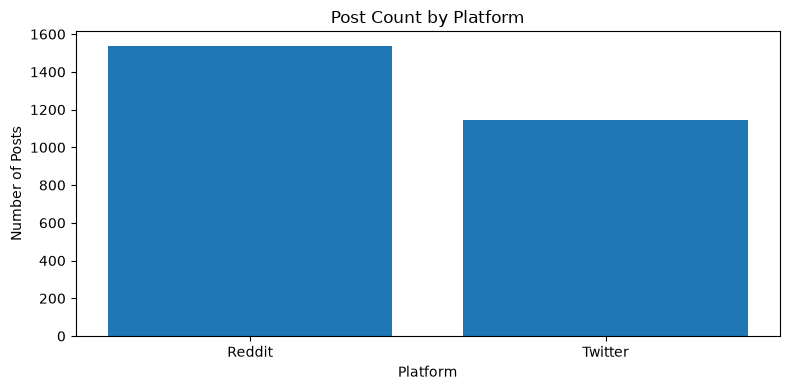


✅ Cell 12 completed successfully


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

print("🔹 STEP 12 – PLATFORM COMPARISON")
print("=" * 70)

# ------------------------------------------------
# 1. Query engagement by platform
# ------------------------------------------------
query2 = """
SELECT
    p.PlatformName AS Platform,
    COUNT(*) AS PostCount,
    SUM(f.Likes) AS TotalLikes,
    SUM(f.Comments) AS TotalComments,
    AVG(f.EngagementScore) AS AvgEngagement
FROM FactSocialEngagement f
INNER JOIN DimPlatform p
    ON f.PlatformKey = p.PlatformKey
GROUP BY p.PlatformName
ORDER BY PostCount DESC
"""

platform_stats = pd.read_sql(query2, engine)

# ------------------------------------------------
# 2. Clean and format numeric columns
# ------------------------------------------------
platform_stats = platform_stats.copy()

numeric_cols = [
    "PostCount",
    "TotalLikes",
    "TotalComments",
    "AvgEngagement"
]

platform_stats[numeric_cols] = (
    platform_stats[numeric_cols]
    .fillna(0)
)

platform_stats["PostCount"] = (
    platform_stats["PostCount"]
    .astype(int)
)

platform_stats["TotalLikes"] = (
    platform_stats["TotalLikes"]
    .astype(int)
)

platform_stats["TotalComments"] = (
    platform_stats["TotalComments"]
    .astype(int)
)

platform_stats["AvgEngagement"] = (
    platform_stats["AvgEngagement"]
    .round(2)
)

# ------------------------------------------------
# 3. Display results
# ------------------------------------------------
print("\n📊 ENGAGEMENT BY PLATFORM")
print("=" * 70)

display(
    platform_stats.style.hide(axis="index")
)

# ------------------------------------------------
# 4. Visualization – Post Count
# ------------------------------------------------
plt.figure(figsize=(8, 4))

plt.bar(
    platform_stats["Platform"],
    platform_stats["PostCount"]
)

plt.title("Post Count by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")

plt.tight_layout()
plt.show()

print("\n✅ Cell 12 completed successfully")
print("=" * 70)

🔹 STEP 13 – TIME-BASED ENGAGEMENT ANALYSIS

📅 ENGAGEMENT OVER TIME (2024+)


Year,Month,MonthName,PostCount,TotalEngagement
2024,1,January,41,270
2024,2,February,43,427
2024,3,March,28,410
2024,4,April,18,492
2024,5,May,10,204
2024,6,June,19,169
2024,7,July,8,62
2024,8,August,26,472
2024,9,September,12,263
2024,10,October,9,251



🔥 PEAK ENGAGEMENT PERIOD
----------------------------------------------------------------------
• Period            : 2025-10
• Total Engagement  : 32,515
• Post Count        : 1,347


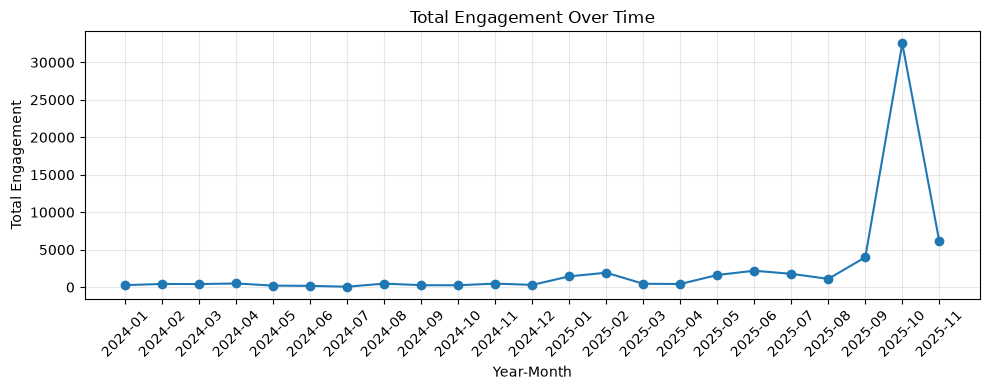


✅ Cell 13 completed successfully


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print("🔹 STEP 13 – TIME-BASED ENGAGEMENT ANALYSIS")
print("=" * 70)

# ------------------------------------------------
# 1. Query: Engagement over time (by year & month)
# ------------------------------------------------
query3 = """
SELECT
    d.Year,
    d.Month,
    d.MonthName,
    COUNT(*) AS PostCount,
    SUM(f.EngagementScore) AS TotalEngagement
FROM FactSocialEngagement f
JOIN DimDate d
    ON f.DateKey = d.DateKey
WHERE d.Year >= 2024
GROUP BY
    d.Year,
    d.Month,
    d.MonthName
ORDER BY
    d.Year,
    d.Month;
"""

time_analysis = pd.read_sql(query3, engine)

# ------------------------------------------------
# 2. Check that data exists
# ------------------------------------------------
if time_analysis.empty:
    raise ValueError("❌ No engagement data found for 2024 or later.")

# ------------------------------------------------
# 3. Format numeric columns
# ------------------------------------------------
time_analysis["PostCount"] = (
    time_analysis["PostCount"]
    .astype(int)
)

time_analysis["TotalEngagement"] = (
    time_analysis["TotalEngagement"]
    .fillna(0)
    .round(0)
    .astype(int)
)

# ------------------------------------------------
# 4. Create Year-Month label
# ------------------------------------------------
time_analysis["YearMonth"] = (
    time_analysis["Year"].astype(str)
    + "-"
    + time_analysis["Month"].astype(str).str.zfill(2)
)

# ------------------------------------------------
# 5. Display results
# ------------------------------------------------
print("\n📅 ENGAGEMENT OVER TIME (2024+)")
print("=" * 70)

display(
    time_analysis[
        [
            "Year",
            "Month",
            "MonthName",
            "PostCount",
            "TotalEngagement"
        ]
    ].style.hide(axis="index")
)

print("=" * 70)

# ------------------------------------------------
# 6. Find highest engagement month
# ------------------------------------------------
peak_month = time_analysis.loc[
    time_analysis["TotalEngagement"].idxmax()
]

print("\n🔥 PEAK ENGAGEMENT PERIOD")
print("-" * 70)
print(
    f"• Period            : {peak_month['YearMonth']}"
)
print(
    f"• Total Engagement  : {peak_month['TotalEngagement']:,}"
)
print(
    f"• Post Count        : {peak_month['PostCount']:,}"
)

# ------------------------------------------------
# 7. Visualization
# ------------------------------------------------
plt.figure(figsize=(10, 4))

plt.plot(
    time_analysis["YearMonth"],
    time_analysis["TotalEngagement"],
    marker="o"
)

plt.grid(alpha=0.3)
plt.title("Total Engagement Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Total Engagement")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n✅ Cell 13 completed successfully")
print("=" * 70)

In [16]:
import pandas as pd

print("🔹 STEP 14 – DATA QUALITY CHECKS")
print("=" * 70)

# ------------------------------------------------
# 1. Record count per table
# ------------------------------------------------
print("\n📊 DATA WAREHOUSE SUMMARY")
print("-" * 70)

tables = [
    "DimCurrency",
    "DimDate",
    "DimPlatform",
    "FactSocialEngagement"
]

table_counts = {}

for table in tables:
    count = pd.read_sql(
        f"SELECT COUNT(*) AS count FROM {table}",
        engine
    ).iloc[0]["count"]

    table_counts[table] = int(count)

    print(f"{table:30s} {int(count):,} rows")

print("-" * 70)

# ------------------------------------------------
# 2. Foreign Key Integrity Checks
# ------------------------------------------------
print("\n🔗 FOREIGN KEY INTEGRITY CHECKS")
print("-" * 70)

# Currency FK
currency_orphans = pd.read_sql(
    """
    SELECT COUNT(*) AS OrphanCount
    FROM FactSocialEngagement f
    LEFT JOIN DimCurrency c
        ON f.CurrencyKey = c.CurrencyKey
    WHERE c.CurrencyKey IS NULL
    """,
    engine
).iloc[0]["OrphanCount"]

# Date FK
date_orphans = pd.read_sql(
    """
    SELECT COUNT(*) AS OrphanCount
    FROM FactSocialEngagement f
    LEFT JOIN DimDate d
        ON f.DateKey = d.DateKey
    WHERE d.DateKey IS NULL
    """,
    engine
).iloc[0]["OrphanCount"]

# Platform FK
platform_orphans = pd.read_sql(
    """
    SELECT COUNT(*) AS OrphanCount
    FROM FactSocialEngagement f
    LEFT JOIN DimPlatform p
        ON f.PlatformKey = p.PlatformKey
    WHERE p.PlatformKey IS NULL
    """,
    engine
).iloc[0]["OrphanCount"]

print(f"Currency FK orphan records : {int(currency_orphans):,}")
print(f"Date FK orphan records     : {int(date_orphans):,}")
print(f"Platform FK orphan records : {int(platform_orphans):,}")

total_orphans = (
    int(currency_orphans)
    + int(date_orphans)
    + int(platform_orphans)
)

if total_orphans == 0:
    print("\n✅ Foreign key integrity check passed")
else:
    print(
        f"\n⚠️ Warning: {total_orphans:,} orphaned "
        "foreign-key relationships detected"
    )

# ------------------------------------------------
# 3. Null / Missing Value Checks
# ------------------------------------------------
print("\n🔎 NULL VALUE CHECK")
print("-" * 70)

null_check = pd.read_sql(
    """
    SELECT
        SUM(CASE WHEN CurrencyKey IS NULL THEN 1 ELSE 0 END) AS NullCurrency,
        SUM(CASE WHEN DateKey IS NULL THEN 1 ELSE 0 END) AS NullDate,
        SUM(CASE WHEN PlatformKey IS NULL THEN 1 ELSE 0 END) AS NullPlatform,
        SUM(CASE WHEN PostId IS NULL THEN 1 ELSE 0 END) AS NullPostId
    FROM FactSocialEngagement
    """,
    engine
).iloc[0]

print(f"Null CurrencyKey : {int(null_check['NullCurrency']):,}")
print(f"Null DateKey     : {int(null_check['NullDate']):,}")
print(f"Null PlatformKey : {int(null_check['NullPlatform']):,}")
print(f"Null PostId      : {int(null_check['NullPostId']):,}")

# ------------------------------------------------
# 4. Date Range Coverage
# ------------------------------------------------
print("\n📅 DATE RANGE COVERAGE")
print("-" * 70)

date_range_query = """
SELECT
    MIN(d.FullDate) AS FirstDate,
    MAX(d.FullDate) AS LastDate
FROM FactSocialEngagement f
INNER JOIN DimDate d
    ON f.DateKey = d.DateKey
"""

date_range = pd.read_sql(
    date_range_query,
    engine
)

first_date = date_range.iloc[0]["FirstDate"]
last_date = date_range.iloc[0]["LastDate"]

print(f"Data coverage period: {first_date} → {last_date}")

# ------------------------------------------------
# 5. Duplicate Post Check
# ------------------------------------------------
print("\n🔁 DUPLICATE POST CHECK")
print("-" * 70)

duplicate_query = """
SELECT
    COUNT(*) AS DuplicateGroups
FROM (
    SELECT
        PostId,
        PlatformKey
    FROM FactSocialEngagement
    GROUP BY PostId, PlatformKey
    HAVING COUNT(*) > 1
) duplicates
"""

duplicate_groups = pd.read_sql(
    duplicate_query,
    engine
).iloc[0]["DuplicateGroups"]

print(
    f"Duplicate PostId/Platform groups: "
    f"{int(duplicate_groups):,}"
)

# ------------------------------------------------
# 6. Final Data Quality Verdict
# ------------------------------------------------
print("\n🏁 DATA QUALITY VERDICT")
print("=" * 70)

if (
    total_orphans == 0
    and int(null_check["NullCurrency"]) == 0
    and int(null_check["NullDate"]) == 0
    and int(null_check["NullPlatform"]) == 0
    and int(null_check["NullPostId"]) == 0
    and int(duplicate_groups) == 0
):
    print("✅ DATA QUALITY CHECK PASSED")
    print("✅ Warehouse relationships are intact")
    print("✅ No critical NULL values detected")
    print("✅ No duplicate PostId/Platform groups detected")
else:
    print("⚠️ DATA QUALITY CHECK IDENTIFIED ISSUES")
    print("Review the warnings above before final reporting.")

print("\n✅ Cell 14 completed successfully")
print("=" * 70)

🔹 STEP 14 – DATA QUALITY CHECKS

📊 DATA WAREHOUSE SUMMARY
----------------------------------------------------------------------
DimCurrency                    78 rows
DimDate                        1,444 rows
DimPlatform                    2 rows
FactSocialEngagement           2,682 rows
----------------------------------------------------------------------

🔗 FOREIGN KEY INTEGRITY CHECKS
----------------------------------------------------------------------
Currency FK orphan records : 0
Date FK orphan records     : 0
Platform FK orphan records : 0

✅ Foreign key integrity check passed

🔎 NULL VALUE CHECK
----------------------------------------------------------------------
Null CurrencyKey : 0
Null DateKey     : 0
Null PlatformKey : 0
Null PostId      : 0

📅 DATE RANGE COVERAGE
----------------------------------------------------------------------
Data coverage period: 2020-12-16 → 2025-11-18

🔁 DUPLICATE POST CHECK
------------------------------------------------------------------

In [17]:
import pandas as pd
from datetime import datetime

print("🔹 STEP 15 – EXPORT DATABASE SCHEMA")
print("=" * 70)

# ------------------------------------------------
# 1. Get warehouse statistics
# ------------------------------------------------

tables = [
    "DimCurrency",
    "DimDate",
    "DimPlatform",
    "FactSocialEngagement"
]

table_counts = {}

for table in tables:
    count = pd.read_sql(
        f"SELECT COUNT(*) AS count FROM {table}",
        engine
    ).iloc[0]["count"]

    table_counts[table] = int(count)

total_records = table_counts["FactSocialEngagement"]

# ------------------------------------------------
# 2. Generate schema documentation
# ------------------------------------------------

schema_doc = f"""
# Noodles Data Warehouse Schema

Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

============================================================
1. ARCHITECTURE
============================================================

The Noodles Data Warehouse uses a Star Schema design.

The warehouse consists of:

- 3 Dimension Tables
- 1 Fact Table
- Foreign-key relationships between the fact and dimension tables


============================================================
2. DIMENSION TABLES
============================================================

DIMCURRENCY

Purpose:
Stores cryptocurrency/token master data.

Columns:
- CurrencyKey       (Primary Key)
- Symbol
- CurrencyName
- BaseCurrency
- Website
- CirculatingSupply
- MaxSupply
- LoadDate

Rows: {table_counts["DimCurrency"]:,}


------------------------------------------------------------

DIMDATE

Purpose:
Provides calendar attributes for time-based analysis.

Columns:
- DateKey       (Primary Key)
- FullDate
- Year
- Quarter
- Month
- Week
- MonthName
- DayOfMonth
- DayOfWeek
- DayName
- IsWeekend

Rows: {table_counts["DimDate"]:,}


------------------------------------------------------------

DIMPLATFORM

Purpose:
Stores the social media platforms used in the analysis.

Columns:
- PlatformKey          (Primary Key)
- PlatformName
- PlatformDescription

Current platforms:
- Twitter / X
- Reddit

Rows: {table_counts["DimPlatform"]:,}


============================================================
3. FACT TABLE
============================================================

FACTSOCIALENGAGEMENT

Purpose:
Stores social media engagement measurements.

Columns:
- EngagementKey      (Primary Key)
- CurrencyKey        (Foreign Key)
- DateKey            (Foreign Key)
- PlatformKey        (Foreign Key)
- PostId
- Likes
- Retweets
- Comments
- Impressions
- EngagementScore
- LoadDate

Rows: {table_counts["FactSocialEngagement"]:,}


============================================================
4. STAR SCHEMA RELATIONSHIPS
============================================================

DimCurrency
     |
     |
     +------ FactSocialEngagement ------+
     |                                  |
     |                                  |
  DimDate                          DimPlatform


Foreign Keys:

FactSocialEngagement.CurrencyKey
    -> DimCurrency.CurrencyKey

FactSocialEngagement.DateKey
    -> DimDate.DateKey

FactSocialEngagement.PlatformKey
    -> DimPlatform.PlatformKey


============================================================
5. FACT TABLE GRAIN
============================================================

One row per social media post.

Each fact record represents a social media engagement event
associated with:

- A cryptocurrency/token
- A calendar date
- A social media platform


============================================================
6. WAREHOUSE STATISTICS
============================================================

DimCurrency              : {table_counts["DimCurrency"]:,} rows
DimDate                  : {table_counts["DimDate"]:,} rows
DimPlatform              : {table_counts["DimPlatform"]:,} rows
FactSocialEngagement     : {table_counts["FactSocialEngagement"]:,} rows

Total Fact Records       : {total_records:,}


============================================================
7. DATA SOURCES
============================================================

The warehouse combines:

- Cryptocurrency/token JSON data
- Twitter/X post data
- Reddit post engagement data
- Task 4 currency enrichment data


============================================================
8. ANALYTICAL CAPABILITIES
============================================================

The warehouse supports:

- Token engagement performance
- Platform performance
- Engagement trends over time
- Likes and comments
- Social media activity volume
- Cross-platform comparisons
- Top-performing tokens
- Time-based engagement patterns


============================================================
9. DATA QUALITY
============================================================

The warehouse was validated using:

- Foreign-key integrity checks
- NULL-value checks
- Duplicate PostId/Platform checks
- Date-range coverage checks
- Record-count validation

Latest validation result:

DATA QUALITY CHECK PASSED


============================================================
10. PROJECT STATUS
============================================================

Data warehouse build       : COMPLETE
Data ingestion             : COMPLETE
Analytical queries         : COMPLETE
Data quality validation    : COMPLETE
Schema documentation       : GENERATED


============================================================
11. PORTFOLIO PROJECT SUMMARY
============================================================

The Noodles Data Warehouse demonstrates an end-to-end
data analytics workflow:

Raw Data
    ->
Python / Pandas
    ->
Data Cleaning
    ->
MySQL Data Warehouse
    ->
Star Schema
    ->
SQL Analysis
    ->
Data Quality Validation
    ->
Business Insights

"""

# ------------------------------------------------
# 3. Save schema documentation
# ------------------------------------------------

output_file = "data_warehouse_schema.md"

with open(output_file, "w", encoding="utf-8") as f:
    f.write(schema_doc)

print(f"✅ Schema documentation saved to: {output_file}")

# ------------------------------------------------
# 4. Display documentation
# ------------------------------------------------

print("\n📄 SCHEMA DOCUMENTATION")
print("=" * 70)
print(schema_doc)

# ------------------------------------------------
# 5. Keep database connection open
# ------------------------------------------------

print("\n🔗 Database connection remains open.")
print("\n✅ Cell 15 completed successfully")
print("=" * 70)


🔹 STEP 15 – EXPORT DATABASE SCHEMA
✅ Schema documentation saved to: data_warehouse_schema.md

📄 SCHEMA DOCUMENTATION

# Noodles Data Warehouse Schema

Generated: 2026-08-19 22:41:21

1. ARCHITECTURE

The Noodles Data Warehouse uses a Star Schema design.

The warehouse consists of:

- 3 Dimension Tables
- 1 Fact Table
- Foreign-key relationships between the fact and dimension tables


2. DIMENSION TABLES

DIMCURRENCY

Purpose:
Stores cryptocurrency/token master data.

Columns:
- CurrencyKey       (Primary Key)
- Symbol
- CurrencyName
- BaseCurrency
- Website
- CirculatingSupply
- MaxSupply
- LoadDate

Rows: 78


------------------------------------------------------------

DIMDATE

Purpose:
Provides calendar attributes for time-based analysis.

Columns:
- DateKey       (Primary Key)
- FullDate
- Year
- Quarter
- Month
- Week
- MonthName
- DayOfMonth
- DayOfWeek
- DayName
- IsWeekend

Rows: 1,444


------------------------------------------------------------

DIMPLATFORM

Purpose:
Stores

In [18]:
import pandas as pd
from IPython.display import display

print("🔍 POST-LOAD QA CHECK")
print("=" * 70)

# ------------------------------------------------
# 1. Platform-level fact table check
# ------------------------------------------------

qa = pd.read_sql(
    """
    SELECT
        dp.PlatformName,
        COUNT(*) AS FactRows,
        SUM(f.Likes) AS TotalLikes,
        ROUND(AVG(f.EngagementScore), 2) AS AvgEngagement
    FROM FactSocialEngagement f
    JOIN DimPlatform dp
        ON f.PlatformKey = dp.PlatformKey
    GROUP BY dp.PlatformName
    ORDER BY dp.PlatformName
    """,
    engine
)

print("\n📊 PLATFORM QA")
print("-" * 70)

display(qa.style.hide(axis="index"))

# ------------------------------------------------
# 2. Date coverage check
# ------------------------------------------------

dates = pd.read_sql(
    """
    SELECT
        MIN(d.FullDate) AS MinDate,
        MAX(d.FullDate) AS MaxDate,
        COUNT(DISTINCT d.FullDate) AS DistinctDays
    FROM FactSocialEngagement f
    JOIN DimDate d
        ON f.DateKey = d.DateKey
    """,
    engine
)

print("\n📅 DATE COVERAGE")
print("-" * 70)

print(dates.to_string(index=False))

# ------------------------------------------------
# 3. Foreign-key integrity check
# ------------------------------------------------

currency_orphans = pd.read_sql(
    """
    SELECT COUNT(*) AS Orphans
    FROM FactSocialEngagement f
    LEFT JOIN DimCurrency c
        ON f.CurrencyKey = c.CurrencyKey
    WHERE c.CurrencyKey IS NULL
    """,
    engine
).iloc[0]["Orphans"]

date_orphans = pd.read_sql(
    """
    SELECT COUNT(*) AS Orphans
    FROM FactSocialEngagement f
    LEFT JOIN DimDate d
        ON f.DateKey = d.DateKey
    WHERE d.DateKey IS NULL
    """,
    engine
).iloc[0]["Orphans"]

platform_orphans = pd.read_sql(
    """
    SELECT COUNT(*) AS Orphans
    FROM FactSocialEngagement f
    LEFT JOIN DimPlatform p
        ON f.PlatformKey = p.PlatformKey
    WHERE p.PlatformKey IS NULL
    """,
    engine
).iloc[0]["Orphans"]

print("\n🔗 FOREIGN KEY QA")
print("-" * 70)

print(f"Currency FK orphans : {currency_orphans}")
print(f"Date FK orphans     : {date_orphans}")
print(f"Platform FK orphans : {platform_orphans}")

# ------------------------------------------------
# 4. Duplicate PostId / Platform check
# ------------------------------------------------

duplicates = pd.read_sql(
    """
    SELECT
        PostId,
        PlatformKey,
        COUNT(*) AS DuplicateCount
    FROM FactSocialEngagement
    GROUP BY PostId, PlatformKey
    HAVING COUNT(*) > 1
    """,
    engine
)

print("\n🔁 DUPLICATE POST QA")
print("-" * 70)

print(f"Duplicate PostId/Platform groups: {len(duplicates):,}")

# ------------------------------------------------
# 5. Final verdict
# ------------------------------------------------

print("\n" + "=" * 70)
print("🏆 FINAL POST-LOAD QA VERDICT")
print("=" * 70)

total_orphans = (
    currency_orphans
    + date_orphans
    + platform_orphans
)

if total_orphans == 0 and len(duplicates) == 0:
    print("✅ POST-LOAD QA PASSED")
    print("✅ Foreign-key relationships are intact")
    print("✅ No duplicate PostId/Platform groups detected")
    print("✅ Warehouse is ready for Power BI")
else:
    print("⚠️ QA FOUND ISSUES – REVIEW RESULTS ABOVE")

print("=" * 70)

🔍 POST-LOAD QA CHECK

📊 PLATFORM QA
----------------------------------------------------------------------


PlatformName,FactRows,TotalLikes,AvgEngagement
Reddit,1538,13519.000000,26.670000
Twitter,1144,7284.000000,18.890000



📅 DATE COVERAGE
----------------------------------------------------------------------
   MinDate    MaxDate  DistinctDays
2020-12-16 2025-11-18           619

🔗 FOREIGN KEY QA
----------------------------------------------------------------------
Currency FK orphans : 0
Date FK orphans     : 0
Platform FK orphans : 0

🔁 DUPLICATE POST QA
----------------------------------------------------------------------
Duplicate PostId/Platform groups: 0

🏆 FINAL POST-LOAD QA VERDICT
✅ POST-LOAD QA PASSED
✅ Foreign-key relationships are intact
✅ No duplicate PostId/Platform groups detected
✅ Warehouse is ready for Power BI
